csv 파일 구조  
줄 바꿈으로 구분되는 1개 이상의 행(레코드)으로 구성  
각 행은 1개 이상의 열(필드)로 구성  
필드는 큰따옴표로 둘러싸도 됨  



In [1]:
import pandas as pd

data = [[10, 20, 30]]
series = pd.Series(data)
print(series)

0    [10, 20, 30]
dtype: object


In [2]:
data = {'a':10, 'b': 20, 'c':30}
series = pd.Series(data)
print(series)

a    10
b    20
c    30
dtype: int64


In [3]:
data = [
    [1, 'Alice', 30],
    [2, 'Bob', 35],
    [3, 'Charlie', 25]
]
df = pd.DataFrame(data, columns=['ID', 'Name', 'Age'])
print(df)

   ID     Name  Age
0   1    Alice   30
1   2      Bob   35
2   3  Charlie   25


In [5]:
data = {'ID':[1,2,3],
        'Name': ['Alice', 'Bob', 'Charlie'],
        'Age':[30,35,25]}
df = pd.DataFrame(data)
print(df)

   ID     Name  Age
0   1    Alice   30
1   2      Bob   35
2   3  Charlie   25


In [ ]:
# 열 추가
df['Salary'] = [50000, 60000, 70000]
print(df)

In [ ]:
# 행 추가
df.loc[len(df)] = [4, 'David', 40, 80000]

In [9]:
# 데이터 조작 - 데이터 연결
# DataFrame 행 연결, concat() 함수 매개변수는 데이터 프레임 리스트형

data2 = {'ID':[5,6],
         'Name':['Eve', 'Frank'],
         'Age':[28,33]}
df2 = pd.DataFrame(data2)
concated = pd.concat([df,df2])

In [13]:
# 데이터 병합
# DataFrame 열 병합

data3 = {'ID': [1,2,3,4,5,6],
         'Department':['HR','Engineering','Sales','R&D', 'Finance', 'Planning']}
df3 = pd.DataFrame(data3)
merged = pd.merge(concated, df3)
print(merged)

   ID     Name  Age   Salary   Department
0   1    Alice   30  50000.0           HR
1   2      Bob   35  60000.0  Engineering
2   3  Charlie   25  70000.0        Sales
3   4    David   40  80000.0          R&D
4   5      Eve   28      NaN      Finance
5   6    Frank   33      NaN     Planning


In [14]:
# 데이터 상위 5개 행 보기
print(df.head())

# 데이터 하위 5개 행 보기
print(df.tail())

# 데이터 정보 요약
print(df.info())

# 기술 통계
print(df.describe())

# 열 선택
print(df['Name'])

# 조건 필터링
filtered = df[df['Age']>30]
print(filtered)

# 데이터 정렬
sorted_df = df.sort_values(by='Age')

# 데이터 처리 - 결측치 처리
print(df.isnull().sum())

# 데이터 처리 - 결측치 채우기
meanVal = merged['Salary'].mean()
merged['Salary'] = merged['Salary'].fillna(meanVal)
print(merged)

# 데이터 처리 - 중복 데이터 처리
data1 = {'ID':[1,3],
         'Name':['Alice','Charlie'],
         'Age':[30,25],
         'Salary':[50000,70000],
         'Department':['HR','Sales']}
df1 = pd.DataFrame(data1)
df1 = pd.concat([merged,df1])
print(df1)
print(df1.duplicated())

   ID     Name  Age  Salary
0   1    Alice   30   50000
1   2      Bob   35   60000
2   3  Charlie   25   70000
3   4    David   40   80000
   ID     Name  Age  Salary
0   1    Alice   30   50000
1   2      Bob   35   60000
2   3  Charlie   25   70000
3   4    David   40   80000
<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      4 non-null      int64 
 1   Name    4 non-null      object
 2   Age     4 non-null      int64 
 3   Salary  4 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 160.0+ bytes
None
             ID        Age        Salary
count  4.000000   4.000000      4.000000
mean   2.500000  32.500000  65000.000000
std    1.290994   6.454972  12909.944487
min    1.000000  25.000000  50000.000000
25%    1.750000  28.750000  57500.000000
50%    2.500000  32.500000  65000.000000
75%    3.250000  36.250000  72500.000000
max    4.000000  40.0

Numpy  
다차원 배열 및 행렬 연산 지원 라이브러리  
과학 계산을 위한 다양한 함수 제공  

In [29]:
import numpy as np

# 배열 생성

# arr = np.array([1,2,3,4,5])
# print(arr)
# print(arr.shape)
# print(arr.dtype)
# identity1 = np.eye(3,3)
# identity2 = np.identity(3)
# print(identity1)
# print(identity2)

# 브로드캐스팅
# 배열 간 연산
arr1 = np.array([1,2,3])
arr2 = np.array([[1],[2],[3]])
result = arr1 + arr2
print(result)

# 브로드캐스팅 규칙:

# arr1 = np.array([1, 2, 3])        # shape: (3,)   → 1행 3열처럼 취급
# arr2 = np.array([[1],[2],[3]])     # shape: (3, 1) → 3행 1열

# shape이 다를 때 자동으로 늘려서 계산함
# arr1:        [1, 2, 3]       → (1, 3) 으로 확장
#              [1, 2, 3]
#              [1, 2, 3]

# arr2:        [1]             → (3, 3) 으로 확장
#              [2]
#              [3]
#              ↓
#              [1, 1, 1]
#              [2, 2, 2]
#              [3, 3, 3]

# **덧셈 결과:**
# ```
# [1, 2, 3]     [1, 1, 1]     [2, 3, 4]
# [1, 2, 3]  +  [2, 2, 2]  =  [3, 4, 5]
# [1, 2, 3]     [3, 3, 3]     [4, 5, 6]

# 선형 대수 연산
# 행렬 곱
matrix1 = np.array([[1,2],[3,4]])
matrix2 = np.array([[5,6],[7,8]])
result = np.dot(matrix1, matrix2)
print('-'*5)

print(matrix1)
print(result)
print('-'*5)

arr = np.array([[1,2,3],[4,5,6]])
print(arr[1,2])
print('-'*5)

arr = np.array([1,2,3,4,5])
filtered = arr[arr>3]
print(filtered)
print('-'*5)

# Pandas DataFrame으로 변환
df = pd.DataFrame(arr, columns=['Value'])
print(df)
print('-'*5)



[[2 3 4]
 [3 4 5]
 [4 5 6]]
-----
[[1 2]
 [3 4]]
[[19 22]
 [43 50]]
-----
6
-----
[4 5]
-----
   Value
0      1
1      2
2      3
3      4
4      5
-----


matplotlib  
데이터 시각화 개요  
데이터를 그래프로 표현하여 이해를 돕는 과정  
의사 결정 및 통찰력 발견에 필수적  

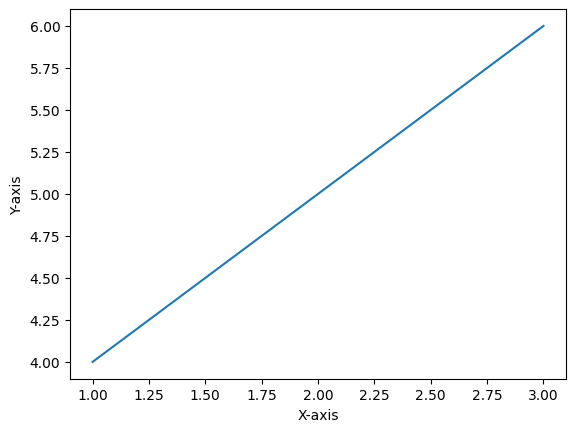

In [30]:
# 18차시 과제

import matplotlib.pyplot as plt
plt.plot([1, 2, 3], [4, 5, 6])
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [ ]:
import pandas as pd

# 6. data.csv라는 파일이 주어졌을 때, 해당 데이터를 불러와서 기초 통계를 계산하는 프로그램을 작성하세요. 
# pandas를 사용하여 data.csv를 불러오고, 각 열의 평균(mean), 최댓값(max), 최솟값(min) 을 출력하세요.

try:
    df = pd.read_csv('/home/lyj/study_archive/bootcamp/python/data.csv')

    age_mean = df['Age'].mean()
    age_max = df['Age'].max()
    age_min = df['Age'].min()
    salary_mean = df['Salary'].mean()
    salary_max = df['Salary'].max()
    salary_min = df['Salary'].min()

    print(f"Age 평균: {age_mean}, 최댓값: {age_max}, 최솟값: {age_min}")
    print(f"Salary 평균: {salary_mean}, 최댓값: {salary_max}, 최솟값: {salary_min}")

except FileNotFoundError:
    print("data.csv 파일을 찾을 수 없습니다.")


Age 평균: 29.5, 최댓값: 35, 최솟값: 25
Salary 평균: 58750.0, 최댓값: 70000, 최솟값: 50000


In [ ]:
# 7. 주어진 데이터프레임에서 30세 이상이면서 연봉이 60000 이상인 사람만 필터링하여 출력하세요.

filtered = df[(df['Age']>=30) & (df['Salary']>=60000)]
print(filtered)

   Name  Age  Salary
1   Bob   30   60000
3  Dave   35   70000


In [ ]:
# 8. NumPy 배열을 사용하여 다음 연산을 수행하세요.
# 1부터 10까지의 정수 배열을 생성
# 배열의 모든 원소를 제곱
# 배열의 평균, 최댓값, 최솟값 출력
# 출력 결과:
# 원본 배열: [ 1  2  3  4  5  6  7  8  9 10]
# 제곱 배열: [  1   4   9  16  25  36  49  64  81 100]
# 평균: 38.5, 최댓값: 100, 최솟값: 1

import numpy as np

array1 = np.arange(1,11)
array2 = array1 ** 2

mean_arr = array2.mean()
max_arr = array2.max()
min_arr = array2.min()

# 결과 출력
print(f"원본 배열: {array1}")
print(f"제곱 배열: {array2}")
print(f"평균: {mean_arr}, 최댓값: {max_arr}, 최솟값: {min_arr}")


원본 배열: [ 1  2  3  4  5  6  7  8  9 10]
제곱 배열: [  1   4   9  16  25  36  49  64  81 100]
평균: 38.5, 최댓값: 100, 최솟값: 1


In [ ]:
# 9. NumPy를 사용하여 3x4 크기의 난수 행렬을 생성하고, 각 행(row)에서 최댓값을 찾아 출력하세요.
# 출력 결과:
# 원본 행렬:
# [[ 3 10  5  7]
#  [ 6  8  2  1]
#  [12  4 11  9]]
# 각 행의 최댓값: [10  8 12]

# 2. 각 행(row)에서 최댓값 찾기 (axis=1은 가로 방향, 즉 행을 의미)
# max_per_row = matrix.max(axis=1) # 이 것으로도 최대값 찾기 가능

arr1 = np.random.randint(1,20,(3,4))
print("원본 행렬:")
print(arr1)

max_list = []
for row in arr1:
    row_max = max(row)
    max_list.append(row_max)

row_max_arr = np.array(max_list)

print(f"각 행의 최댓값: {row_max_arr}")

원본 행렬:
[[14 13  3  8]
 [14  6 15 10]
 [ 5 17 19 14]]
각 행의 최댓값: [14 15 19]


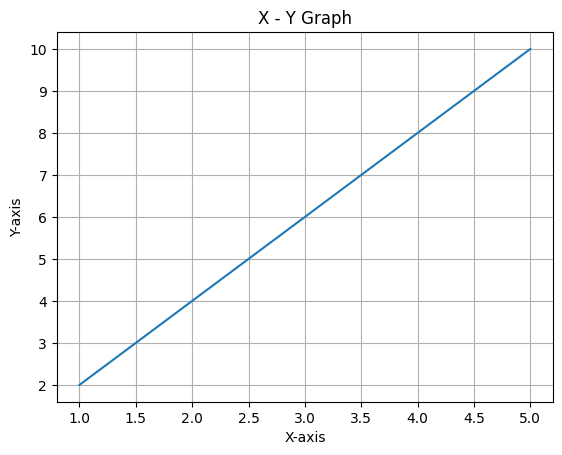

In [42]:
# 10. x값이 [1, 2, 3, 4, 5]일 때, y값이 [2, 4, 6, 8, 10]인 선 그래프를 그려보세요.
# 그래프에는 제목, x/y축 라벨, 그리드(grid) 를 추가하세요.
# 출력 결과:
# X축: 1~5
# Y축: 2~10
# 직선 그래프 표시

import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]
plt.plot(x, y)
plt.title("X - Y Graph")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid()
plt.show()